In [96]:
from sdk_core import configure
from sdk_core import TwMarketData
# configure()

tw = TwMarketData()
# 取得還原股價
df = tw.get_security_price_adjusted("2025-12-31", "2330")

import os
import numpy as np
from tqdm import tqdm
import time
import datetime
import matplotlib.pyplot as plt
import pandas as pd
import polars as pl
# 將最大顯示欄位數量設為 None（代表無上限）
pd.set_option('display.max_columns', None)

import sys
import os
sys.path.append(os.path.abspath(os.path.join('..')))

import pyarrow as pa
schema = pa.schema([
    ('price', pa.decimal128(10, 4)), 
    # 其他欄位如果沒特別指定，pyarrow 會自動推斷
])

from backTest import BackTest
from factorAnalyzer import FactorAnalyzer_Polars


In [97]:

folder_path = './data'  # 資料夾路徑
files = os.listdir(folder_path)

# 過濾掉資料夾，只留下檔案
file_names = np.array([f for f in files if os.path.isfile(os.path.join(folder_path, f))])
file_names.sort()
print(file_names[-5:])

['20260312.parquet' '20260313.parquet' '20260316.parquet'
 '20260317.parquet' '20260318.parquet']


In [98]:
data = []

# 範例：處理 100 個檔案
for f in tqdm (file_names[:]): 
    targetLabel = 'BidPrice1' 
    rankThres_btn = 0
    rankThres = 100.1
    stock_df = pd.read_parquet( f'{folder_path}/{f}' )[lambda x : x[targetLabel] * x.BidPrice1 > 0]
    try : 
        stock_df['ToRef'] = ((stock_df['BidPrice1'] - stock_df.RefPrice) / stock_df.RefPrice ).round(4)
        # stock_df['TakerSell_CloseBP'] = ((stock_df[targetLabel]- stock_df.Close) / stock_df[targetLabel] * 10000)
        # stock_df.loc[ stock_df.FutureHigh > stock_df.RefPrice*1.09 , 'TakerSell_CloseBP'] = ((stock_df[targetLabel] - stock_df.FutureHigh) / stock_df[targetLabel] * 10000)
        stock_df['TakerSell_CloseBP'] = ((stock_df[targetLabel]- stock_df.Close) / stock_df[targetLabel] * 10000)
        stock_df.loc[ stock_df.FutureHigh > stock_df.RefPrice*1.08 , 'TakerSell_CloseBP'] = ((stock_df[targetLabel] - stock_df.RefPrice*1.08 - stock_df.TickSize*2) / stock_df[targetLabel] * 10000)
        PriceCondition = (stock_df.ToRef > 0) & (stock_df.ToRef < 0.05)
        # seqCondition = (stock_df.BidPrice1.diff()!= 0)
        AmountCondition = (stock_df.day_amount_rank <= rankThres) | (stock_df.AmountRank <= rankThres) 
        # AmountCondition2 = (stock_df.day_amount_rank > rankThres_btn) & (stock_df.AmountRank > rankThres_btn)
        # preMarketCondition = (stock_df.day_amount_rank <= 50.1) | (stock_df.AmountRank <= 50.1)
        temp = stock_df[ PriceCondition & AmountCondition].reset_index(drop=True)
        temp['Date'] = f.split('.')[0]
        data.append(temp)
    except : 
        print('Filled in ', f)
        continue
        # break       
    # if f.split('.')[0] == '20260309':
    #     break

  0%|          | 2/769 [00:00<00:46, 16.61it/s]

Filled in  20230104.parquet


 97%|█████████▋| 745/769 [00:51<00:02,  8.67it/s]

Filled in  20260130.parquet


100%|██████████| 769/769 [00:53<00:00, 14.34it/s]


In [99]:
signal_df = pd.concat(data).reset_index(drop=True)

In [100]:
priceReturnColumn = ["TransTime", "QuoteCode", "ChannelSeq","TotalFillLots","BidPrice1","BidLots1", "AskPrice1","AskLots1", "RecordHigh","FutureHigh", "RefPrice" , "Close" , "Open", "Spread", "TakerSell_CloseBP" ]
signal_df[:][priceReturnColumn + ['ToRef','FillLots_atLow','day_amount_rank', 'AmountRank', 'TimeSlot','TransTime_tb']].head(10)

,TransTime,QuoteCode,ChannelSeq,TotalFillLots,BidPrice1,BidLots1,AskPrice1,AskLots1,RecordHigh,FutureHigh,RefPrice,Close,Open,Spread,TakerSell_CloseBP,ToRef,FillLots_atLow,day_amount_rank,AmountRank,TimeSlot,TransTime_tb
0,2023-01-05 09:00:21.022822,1101,100950,597,34.20,1,34.25,20,34.20,34.7,33.5,34.45,34.15,1.0,-73.099415,0.0209,-415,53.0,NaN,None,NaT
1,2023-01-05 09:00:26.569747,1101,107081,704,34.25,1,34.30,59,34.25,34.7,33.5,34.45,34.15,1.0,-58.394161,0.0224,-472,53.0,NaN,None,NaT
2,2023-01-05 09:00:26.809839,1101,107272,714,34.20,163,34.30,60,34.25,34.7,33.5,34.45,34.15,2.0,-73.099415,0.0209,-482,53.0,NaN,None,NaT
3,2023-01-05 09:00:27.384746,1101,107773,751,34.25,1,34.30,31,34.30,34.7,33.5,34.45,34.15,1.0,-58.394161,0.0224,-445,53.0,NaN,None,NaT
4,2023-01-05 09:00:27.813290,1101,108219,753,34.20,166,34.25,2,34.30,34.7,33.5,34.45,34.15,1.0,-73.099415,0.0209,-445,53.0,NaN,None,NaT
5,2023-01-05 09:00:28.077559,1101,108496,755,34.25,1,34.30,30,34.30,34.7,33.5,34.45,34.15,1.0,-58.394161,0.0224,-443,53.0,NaN,None,NaT
6,2023-01-05 09:00:31.740176,1101,112071,789,34.30,1,34.35,56,34.30,34.7,33.5,34.45,34.15,1.0,-43.731778,0.0239,-415,53.0,NaN,None,NaT
7,2023-01-05 09:00:31.873504,1101,112210,791,34.25,143,34.35,52,34.30,34.7,33.5,34.45,34.15,2.0,-58.394161,0.0224,-417,53.0,NaN,None,NaT
8,2023-01-05 09:00:33.085004,1101,113530,795,34.30,1,34.35,54,34.30,34.7,33.5,34.45,34.15,1.0,-43.731778,0.0239,-413,53.0,NaN,None,NaT
9,2023-01-05 09:00:46.233702,1101,127146,906,34.25,176,34.30,2,34.35,34.7,33.5,34.45,34.15,1.0,-58.394161,0.0224,-452,53.0,NaN,None,NaT


In [101]:
# target_time_str = "13:25:00"
# target_dt = pd.to_datetime(signal_df['TransTime'].dt.date.astype(str) + " " + target_time_str)
# signal_df['RemainSeconds'] = (target_dt - signal_df['TransTime']).dt.total_seconds()
signal_df = signal_df[ (signal_df.TransTime.dt.time < datetime.time(12, 0, 0)) & (signal_df.TrialMatch == 0)].reset_index(drop=True)
signal_df = signal_df[  ((signal_df.Date.astype(int) - 20260220).abs() > 5 )& (signal_df.TakerSell_CloseBP.abs() < 10000) ].reset_index(drop=True)
# signal_df = signal_df[  (signal_df.TakerSell_CloseBP.abs() < 10000) ].reset_index(drop=True)
signal_df['midEdge_300sBP'] = signal_df['midEdge_300sBP']*-1

In [102]:
signal_df.head(1)

,RecvTime,TransTime,QuoteCode,ValueCode,PacketSeq,ChannelSeq,LimitStatus,TrialMatch,InOut,Overshoot,TotalFillLots,BidPrice1,BidPrice2,BidPrice3,BidPrice4,BidPrice5,BidLots1,BidLots2,BidLots3,BidLots4,BidLots5,AskPrice1,AskPrice2,AskPrice3,AskPrice4,AskPrice5,AskLots1,AskLots2,AskLots3,AskLots4,AskLots5,FillPrice,FillLots,BestBidPrice,BestBidLots,BestAskPrice,BestAskLots,OvershootHis,RefPrice,OTC,marketOpen,Open,Close,RecordHigh,RecordLow,FutureHigh,FutureLow,ToLow,ToHigh,Low_High,BidPreMove,AskPreMove,TickSize,TickBP,MidPrice,ToRef,ToOpen,FillLots_atLow,FillLots_atHigh,FillLots_Net,B1_A1B1,B1_B1B5,B12_B1B5,A1_A1A5,A12_A1A5,Spread,SpreadPairID,SpreadPairAsk,SpreadPairBid,SpreadPairSeq,SpreadPairElapsed,SpreadNarrowOrderTime,SpreadNarrowSide,SpreadPairCumLots,PrevSpreadPairLots,RemainSeconds,FutureAsk1_5s,FutureBid1_5s,FutureAsk1_30s,FutureBid1_30s,FutureAsk1_60s,FutureBid1_60s,FutureAsk1_120s,FutureBid1_120s,FutureAsk1_300s,FutureBid1_300s,FutureAsk1_600s,FutureBid1_600s,TakerSell_CloseBP,TakerBuy_CloseBP,midEdge_5sBP,midEdge_30sBP,midEdge_60sBP,midEdge_120sBP,midEdge_300sBP,midEdge_600sBP,allow_day_trade_mark,trading_volume,dealer_hedging_netLots,dealer_netLots,foreign_dealer_netLots,foreign_netLots,investment_netLots,margin_netLots,short_netLots,nextday_allow_day_trade_mark,trading_volume_noOdd,trading_net_volume_noOdd,trading_net_volume_nearClose,avg_bidLots1,avg_askLots1,last_fillLots,last_FillPrice,big_buy_lots,big_buy_ToCloseBP,big_buy_300sBP,big_sell_lots,big_sell_ToCloseBP,big_sell_300sBP,hft_participation,hft_buy_ToCloseBP,hft_buy_300sBP,hft_sell_ToCloseBP,hft_sell_300sBP,negFill_corr,negFill_sell_ToCloseBP,negFill_sell_300sBP,premium_ref_2330_buy_ToCloseBP,premium_open_2330_buy_ToCloseBP,discount_ref_2330_buy_ToCloseBP,discount_open_2330_buy_ToCloseBP,day_amount_rank,day_lots_rank,TransTime_tb,TimeSlot,AmountRank,netAmountRank,TotalFillLotsRank,netTotalFillLotsRank,ToRefRank,ToOpenRank,ToRefWithOTCRank,ToOpenWithOTCRank,ToOpenNegativeCount,ToOpenPositiveCount,Date,FillLots_origin
0,2023-01-05 09:00:21.022822,2023-01-05 09:00:21.022822,1101,1101,773073,100950,0,0,0,0,597,34.2,34.15,34.1,34.05,34.0,1,416,50,59,154,34.25,34.3,34.35,34.4,34.45,20,58,53,71,23,0.0,0,0.0,0,0.0,0,NaN,33.5,False,True,34.15,34.45,34.2,34.15,34.7,34.05,0.0,0.001493,0.0,0.05,0.0,0.05,14.619883,34.225,0.0209,0.002196,-415,85,-415,0.047619,0.001471,0.613235,0.088889,0.346667,1.0,1,34.25,34.15,1,1.776459,1.776459,1.0,74,523,15878,34.3,34.2,34.35,34.3,34.4,34.35,34.35,34.3,34.15,34.1,34.25,34.2,-73.099415,58.394161,7.304602,29.218408,43.827611,29.218408,29.218408,0.0,X,10493097.0,182243.0,592000.0,0.0,-3074323.0,27000.0,284.0,-3.0,X,10413.0,-90796.0,-91259.0,180.302706,242.571005,2254.0,-0.002234,20.0,-29.476874,4.126467,1560.0,-14.964171,-14.952983,0.036689,-44.565533,-9.29368,29.761905,14.869888,-0.999986,13.715065,13.495363,-34.880893,-54.362801,-29.761905,-34.442624,53.0,19.0,NaT,None,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,20230105,NaN


<Axes: xlabel='Date'>

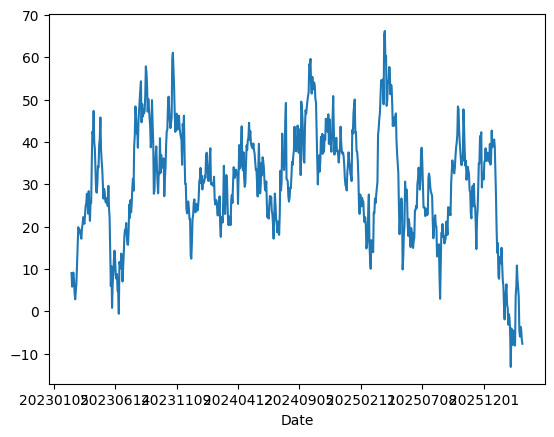

In [103]:
signal_df[:].groupby(['Date','QuoteCode']).TakerSell_CloseBP.mean().reset_index().groupby(['Date']).TakerSell_CloseBP.mean().rolling(30).mean().plot()

In [104]:
signal_df['TakerSell_CloseBP_net'] = signal_df.TakerSell_CloseBP - signal_df.groupby('Date').TakerSell_CloseBP.transform('mean')

In [105]:
signal_df.TakerSell_CloseBP .describe()

count    5.959969e+06
mean     7.809448e+01
std      2.792923e+02
min     -8.892893e+02
25%     -2.812940e+01
50%      9.505703e+01
75%      2.301790e+02
max      1.418919e+03
Name: TakerSell_CloseBP, dtype: float64

# ================= 使用範例 =================
# 假設 df 是您準備好的 Tick 資料
based_columns = ['QuoteCode', 'ChannelSeq', 'InOut', 'Overshoot', 'TotalFillLots', 'BidPrice1','BidLots1', 'BidLots5', 'AskPrice1', 'AskLots1', 'AskLots5', 'FillLots']
feature_columns = ['ToLow', 'ToHigh', 'Low_High', 'TickSize', 'TickBP', 'ToRef', 'ToOpen', 'FillLots_atLow', 'FillLots_atHigh', 'B1_A1B1', 'B1_B1B5', 'B12_B1B5', 'A1_A1A5', 'A12_A1A5', 'Spread', 'SpreadPairID', 'SpreadPairSeq', 'SpreadPairElapsed', 'SpreadNarrowSide', 'SpreadPairCumLots', 'PrevSpreadPairLots', 'RemainSeconds']
cross_columns = ['AmountRank', 'netAmountRank', 'TotalFillLotsRank', 'netTotalFillLotsRank', 'ToRefRank']
day_columns = ['dealer_hedging_netLots', 'dealer_netLots', 'foreign_dealer_netLots', 'foreign_netLots', 'investment_netLots', 'margin_netLots', 'short_netLots', 'nextday_allow_day_trade_mark', 'trading_volume_noOdd', 'big_buy_lots', 'big_buy_ToCloseBP', 'big_buy_300sBP', 'big_sell_lots', 'big_sell_ToCloseBP', 'big_sell_300sBP', 'hft_participation', 'hft_buy_ToCloseBP', 'hft_buy_300sBP', 'hft_sell_ToCloseBP', 'hft_sell_300sBP', 'day_amount_rank', 'day_lots_rank']
# # 
feature = based_columns + feature_columns + cross_columns + day_columns

for label in [ 'TakerSell_CloseBP_net', 'midEdge_300sBP' ] : 
    analyzer = FactorAnalyzer_Polars(signal_df, label_col=label, feature_cols=feature, time_col='Date', weight_col='BidPrice1')
    top_factors_df = analyzer.screen_single_factors(split_date='2024-01-01', n_quantiles=5, spread_threshold=40.0)
    condition_sample = (top_factors_df.Stability > 0.5) & (top_factors_df.IS_Spread * top_factors_df.IS_IC.apply(np.sign) > 40 )
    condition_weight = (top_factors_df.W_Stability > 0.5) & (top_factors_df.IS_W_Spd * top_factors_df.IS_W_IC.apply(np.sign) > 40 )
    top_factors = top_factors_df[ condition_sample | condition_weight ].Feature.to_list()
    break
    # signal_df = train_and_predict_ridge(signal_df, top_factors, label, train_date='2025-01-01')

import pandas as pd
from sklearn.linear_model import Ridge

def train_and_predict_ridge(signal_df, X_list, Y_col):
    print(f"🔍 目前預測目標: {Y_col}")
    
    # 計算 0.1% 的閾值 (threshold)
    total_rows = len(signal_df)
    threshold = total_rows * 0.01
    print(f"📊 資料總筆數: {total_rows} | 0.1% 容忍閾值: {threshold:.2f} 筆")
    
    # 建立分類清單
    cols_to_drop_rows = []
    cols_to_remove_from_X = []
    
    # ==========================================
    # 1. 檢查 X_list 裡面的 NaN 狀況並分類
    # ==========================================
    for col in X_list:
        nan_count = signal_df[col].isna().sum()
        if nan_count > 0:
            if nan_count < threshold:
                # NaN 數量小於 0.1%，標記為準備 dropna (刪除資料列)
                cols_to_drop_rows.append(col)
            else:
                # NaN 數量大於等於 0.1%，標記為準備移除特徵
                cols_to_remove_from_X.append(col)
                
    # ==========================================
    # 2. 執行移除特徵 (Columns) 動作
    # ==========================================
    # 產生真正要進模型的 current_X
    current_X = [col for col in X_list if col not in cols_to_remove_from_X]
    
    if cols_to_remove_from_X:
        print(f"⚠️ 以下特徵 NaN 數量超過閾值，已從 X_list 中移除：")
        for col in cols_to_remove_from_X:
            nan_count = signal_df[col].isna().sum()
            print(f"   - {col} (NaN: {nan_count} 筆)")
            
    # ==========================================
    # 3. 處理 Y 的 NaN 與執行 dropna (刪除資料列)
    # ==========================================
    # 確保 Y 如果有 NaN 也一併剔除該筆資料
    signal_df.replace([np.inf, -np.inf], np.nan, inplace=True)
    
    if signal_df[Y_col].isna().sum() > 0 and Y_col not in cols_to_drop_rows:
        cols_to_drop_rows.append(Y_col)
        
    if cols_to_drop_rows:
        print(f"🧹 以下欄位 NaN 數量極少 (低於閾值)，將直接剔除帶有 NaN 的資料列：")
        for col in cols_to_drop_rows:
            nan_count = signal_df[col].isna().sum()
            print(f"   - {col} (NaN: {nan_count} 筆)")
            
        # 實際執行 dropna，並更新 signal_df
        signal_df = signal_df.dropna(subset=cols_to_drop_rows).copy()
        print(f"✅ 剔除後剩餘資料總筆數: {len(signal_df)}")
        
    # ==========================================
    # 4. 顯示最終要進模型的 X_list
    # ==========================================
    print("-" * 40)
    print(f"🚀 最終使用的 X_list (共 {len(current_X)} 個特徵):")
    print(current_X)
    print("-" * 40)
    
    # 安全機制：如果所有 X 都被砍光了，就拋出錯誤
    if not current_X:
        raise ValueError("所有的 X 特徵都因為 NaN 太多被移除了，無法建立模型！")

    # ==========================================
    # 5. 處理時間與切分訓練集
    # ==========================================
    train_mask = signal_df['Date'].astype(int) < 20240101
    lot_mask = signal_df.groupby(['Date','QuoteCode']).BidPrice1.cumsum()/10 < 500 
    train_df = signal_df[train_mask&lot_mask]
    
    # ==========================================
    # 6. 建立並訓練 Ridge 模型
    # ==========================================
    model = Ridge(alpha=10.0)
    model.fit(train_df[current_X], train_df[Y_col])
    
    # ==========================================
    # 7. 對整份 signal_df 進行預測
    # ==========================================
    pred_col_name = f"{Y_col}_pred"
    signal_df[pred_col_name] = model.predict(signal_df[current_X])
    
    return signal_df

signal_df = train_and_predict_ridge(signal_df, top_factors, label).reset_index(drop=True)

In [106]:
signal_df.head(1)

,RecvTime,TransTime,QuoteCode,ValueCode,PacketSeq,ChannelSeq,LimitStatus,TrialMatch,InOut,Overshoot,TotalFillLots,BidPrice1,BidPrice2,BidPrice3,BidPrice4,BidPrice5,BidLots1,BidLots2,BidLots3,BidLots4,BidLots5,AskPrice1,AskPrice2,AskPrice3,AskPrice4,AskPrice5,AskLots1,AskLots2,AskLots3,AskLots4,AskLots5,FillPrice,FillLots,BestBidPrice,BestBidLots,BestAskPrice,BestAskLots,OvershootHis,RefPrice,OTC,marketOpen,Open,Close,RecordHigh,RecordLow,FutureHigh,FutureLow,ToLow,ToHigh,Low_High,BidPreMove,AskPreMove,TickSize,TickBP,MidPrice,ToRef,ToOpen,FillLots_atLow,FillLots_atHigh,FillLots_Net,B1_A1B1,B1_B1B5,B12_B1B5,A1_A1A5,A12_A1A5,Spread,SpreadPairID,SpreadPairAsk,SpreadPairBid,SpreadPairSeq,SpreadPairElapsed,SpreadNarrowOrderTime,SpreadNarrowSide,SpreadPairCumLots,PrevSpreadPairLots,RemainSeconds,FutureAsk1_5s,FutureBid1_5s,FutureAsk1_30s,FutureBid1_30s,FutureAsk1_60s,FutureBid1_60s,FutureAsk1_120s,FutureBid1_120s,FutureAsk1_300s,FutureBid1_300s,FutureAsk1_600s,FutureBid1_600s,TakerSell_CloseBP,TakerBuy_CloseBP,midEdge_5sBP,midEdge_30sBP,midEdge_60sBP,midEdge_120sBP,midEdge_300sBP,midEdge_600sBP,allow_day_trade_mark,trading_volume,dealer_hedging_netLots,dealer_netLots,foreign_dealer_netLots,foreign_netLots,investment_netLots,margin_netLots,short_netLots,nextday_allow_day_trade_mark,trading_volume_noOdd,trading_net_volume_noOdd,trading_net_volume_nearClose,avg_bidLots1,avg_askLots1,last_fillLots,last_FillPrice,big_buy_lots,big_buy_ToCloseBP,big_buy_300sBP,big_sell_lots,big_sell_ToCloseBP,big_sell_300sBP,hft_participation,hft_buy_ToCloseBP,hft_buy_300sBP,hft_sell_ToCloseBP,hft_sell_300sBP,negFill_corr,negFill_sell_ToCloseBP,negFill_sell_300sBP,premium_ref_2330_buy_ToCloseBP,premium_open_2330_buy_ToCloseBP,discount_ref_2330_buy_ToCloseBP,discount_open_2330_buy_ToCloseBP,day_amount_rank,day_lots_rank,TransTime_tb,TimeSlot,AmountRank,netAmountRank,TotalFillLotsRank,netTotalFillLotsRank,ToRefRank,ToOpenRank,ToRefWithOTCRank,ToOpenWithOTCRank,ToOpenNegativeCount,ToOpenPositiveCount,Date,FillLots_origin,TakerSell_CloseBP_net
0,2023-01-05 09:00:21.022822,2023-01-05 09:00:21.022822,1101,1101,773073,100950,0,0,0,0,597,34.2,34.15,34.1,34.05,34.0,1,416,50,59,154,34.25,34.3,34.35,34.4,34.45,20,58,53,71,23,0.0,0,0.0,0,0.0,0,NaN,33.5,False,True,34.15,34.45,34.2,34.15,34.7,34.05,0.0,0.001493,0.0,0.05,0.0,0.05,14.619883,34.225,0.0209,0.002196,-415,85,-415,0.047619,0.001471,0.613235,0.088889,0.346667,1.0,1,34.25,34.15,1,1.776459,1.776459,1.0,74,523,15878,34.3,34.2,34.35,34.3,34.4,34.35,34.35,34.3,34.15,34.1,34.25,34.2,-73.099415,58.394161,7.304602,29.218408,43.827611,29.218408,29.218408,0.0,X,10493097.0,182243.0,592000.0,0.0,-3074323.0,27000.0,284.0,-3.0,X,10413.0,-90796.0,-91259.0,180.302706,242.571005,2254.0,-0.002234,20.0,-29.476874,4.126467,1560.0,-14.964171,-14.952983,0.036689,-44.565533,-9.29368,29.761905,14.869888,-0.999986,13.715065,13.495363,-34.880893,-54.362801,-29.761905,-34.442624,53.0,19.0,NaT,None,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,20230105,NaN,-224.798022


In [107]:
condition = pd.Series( [True for i in range(len(signal_df))] )
# condition =   (signal_df.ToOpen <0)# (signal_df.Position<200) #(signal_df.big_sell_ToCloseBP > 20 ) & (signal_df.InOut < 0 ) & (signal_df.FillLots > signal_df.big_sell_lots)
# condition = condition | ((signal_df.Spread <= 1 ) & ((signal_df.SpreadPairSeq>5) & (signal_df.SpreadPairID > 5)))
condition = condition #& (signal_df.TakerSell_CloseBP_net_pred > 0) #& ((signal_df.netTotalFillLotsRank>1800)|(signal_df.netAmountRank>1800))
print( signal_df[condition].TakerSell_CloseBP.describe() )
print('')
print( 'cap BP : '+str( round((signal_df[condition].TakerSell_CloseBP * signal_df[condition].BidPrice1).sum() / signal_df[condition].BidPrice1.sum() ,2 ))  )
print( 'averge prod num : '+str( round(signal_df[condition].groupby('Date').QuoteCode.nunique().mean(), 2)  ))

condition_recent = condition & (signal_df.Date.astype(int) > 20260101) #& (signal_df.hft_participation > 0.3) & (signal_df.hft_sell_ToCloseBP > 0 )
print( signal_df[condition_recent].TakerSell_CloseBP.describe() ) 
print('')
print( 'cap BP : '+str( round((signal_df[condition_recent].TakerSell_CloseBP * signal_df[condition_recent].BidPrice1).sum() / signal_df[condition_recent].BidPrice1.sum() ,2 ))  )
print( 'averge prod num : '+str( round(signal_df[condition_recent].groupby('Date').QuoteCode.nunique().mean(), 2)  ))

count    5.959969e+06
mean     7.809448e+01
std      2.792923e+02
min     -8.892893e+02
25%     -2.812940e+01
50%      9.505703e+01
75%      2.301790e+02
max      1.418919e+03
Name: TakerSell_CloseBP, dtype: float64

cap BP : 57.41
averge prod num : 72.95
count    520721.000000
mean         37.349122
std         383.866255
min        -845.098039
25%        -207.939509
50%          52.173913
75%         284.090909
max        1316.872428
Name: TakerSell_CloseBP, dtype: float64

cap BP : -34.15
averge prod num : 70.29


In [108]:
signal_df = signal_df[condition].reset_index(drop=True)
# signal_df = signal_df[condition & ((signal_df.Date.astype(int) < 20260101) |( (signal_df.hft_participation > 0.3) & (signal_df.hft_sell_ToCloseBP > 0 )))].reset_index(drop=True)


In [109]:
print(signal_df.columns.tolist())

['RecvTime', 'TransTime', 'QuoteCode', 'ValueCode', 'PacketSeq', 'ChannelSeq', 'LimitStatus', 'TrialMatch', 'InOut', 'Overshoot', 'TotalFillLots', 'BidPrice1', 'BidPrice2', 'BidPrice3', 'BidPrice4', 'BidPrice5', 'BidLots1', 'BidLots2', 'BidLots3', 'BidLots4', 'BidLots5', 'AskPrice1', 'AskPrice2', 'AskPrice3', 'AskPrice4', 'AskPrice5', 'AskLots1', 'AskLots2', 'AskLots3', 'AskLots4', 'AskLots5', 'FillPrice', 'FillLots', 'BestBidPrice', 'BestBidLots', 'BestAskPrice', 'BestAskLots', 'OvershootHis', 'RefPrice', 'OTC', 'marketOpen', 'Open', 'Close', 'RecordHigh', 'RecordLow', 'FutureHigh', 'FutureLow', 'ToLow', 'ToHigh', 'Low_High', 'BidPreMove', 'AskPreMove', 'TickSize', 'TickBP', 'MidPrice', 'ToRef', 'ToOpen', 'FillLots_atLow', 'FillLots_atHigh', 'FillLots_Net', 'B1_A1B1', 'B1_B1B5', 'B12_B1B5', 'A1_A1A5', 'A12_A1A5', 'Spread', 'SpreadPairID', 'SpreadPairAsk', 'SpreadPairBid', 'SpreadPairSeq', 'SpreadPairElapsed', 'SpreadNarrowOrderTime', 'SpreadNarrowSide', 'SpreadPairCumLots', 'PrevSprea

In [130]:
## 部位留存
signal_df['PosLots'] = signal_df.groupby(['Date', 'QuoteCode']).BidPrice1.transform('cumcount') + 1
signal_df['Position'] = (signal_df.BidPrice1 ).groupby([signal_df.Date, signal_df.QuoteCode]).transform('cumsum') / 10
signalwithRisk_df = signal_df[ (~((signal_df.PosLots >1) & (signal_df.Position > 200))) & (signal_df.BidPrice1<300)].reset_index(drop=True)
# signalwithRisk_df = signal_df[  (~((signal_df.PosLots >1) & (signal_df.Position > 200))) & (signal_df.BidPrice1<1000)].reset_index(drop=True)
# signalwithRisk_df = signal_df[ (signal_df.PosLots ==1)].reset_index(drop=True)


signalwithRisk_df[lambda x : x.Date == '20260317'].reset_index(drop=True).to_csv('20260317_100w.csv')
# signalwithRisk_df[lambda x : x.Date == '20260309'].reset_index(drop=True).to_csv('20260309_oneLots.csv')

In [131]:
signalwithRisk_df[ signalwithRisk_df.Date.astype(int) == signalwithRisk_df.Date.astype(int).max() ].QuoteCode.unique()

<ArrowStringArray>
['1303', '1582', '1711', '1717', '1802', '2303', '2313', '2317', '2327',
 '2337', '2344', '2376', '2382', '2406', '2409', '2421', '2451', '2455',
 '2464', '2481', '2485', '2486', '2603', '2605', '2881', '2891', '3030',
 '3036', '3138', '3231', '3376', '3450', '3481', '3702', '3715', '4906',
 '4927', '4958', '4977', '4989', '5347', '5351', '6147', '6197', '6213',
 '6239', '6282', '6285', '6290', '6770', '8039', '8096', '8110', '8112']
Length: 54, dtype: str

In [132]:
signalwithRisk_df[ (signalwithRisk_df.Date.astype(int) == signalwithRisk_df.Date.astype(int).max()) & (signalwithRisk_df.FutureHigh > signalwithRisk_df.RefPrice *1.09) ].QuoteCode.unique()

<ArrowStringArray>
['2337', '2451', '2485', '3715', '4989', '5351', '6147', '8096']
Length: 8, dtype: str

In [133]:
# 計算所有天數的排名比例
series1 = ( signalwithRisk_df.BidPrice1 * (signalwithRisk_df.TakerSell_CloseBP - 19.3) / 10000 / 10).groupby(signalwithRisk_df.Date).sum()
position = (signalwithRisk_df.BidPrice1 / 10).groupby(signalwithRisk_df.Date).sum()

rank_series = series1.rank(pct=True)

dateSeq = -1

# 取得最後一天的排名
latest_date = series1.index[dateSeq]
latest_rank = rank_series.iloc[dateSeq]

print(f"日期: {latest_date}")
print(f"單邊部位: {position.iloc[dateSeq]:.2f} 萬")
print(f"損益: {series1.iloc[dateSeq]:.2f} 萬")

rank_series = series1.rank()
latest_rank2 = rank_series.iloc[dateSeq]
print(f"排名: {latest_rank2},  {latest_rank :.2%}") # 例如 85.00%，代表贏過歷史 85% 的天數




日期: 20260318
單邊部位: 9505.68 萬
損益: 21.97 萬
排名: 379.0,  49.61%


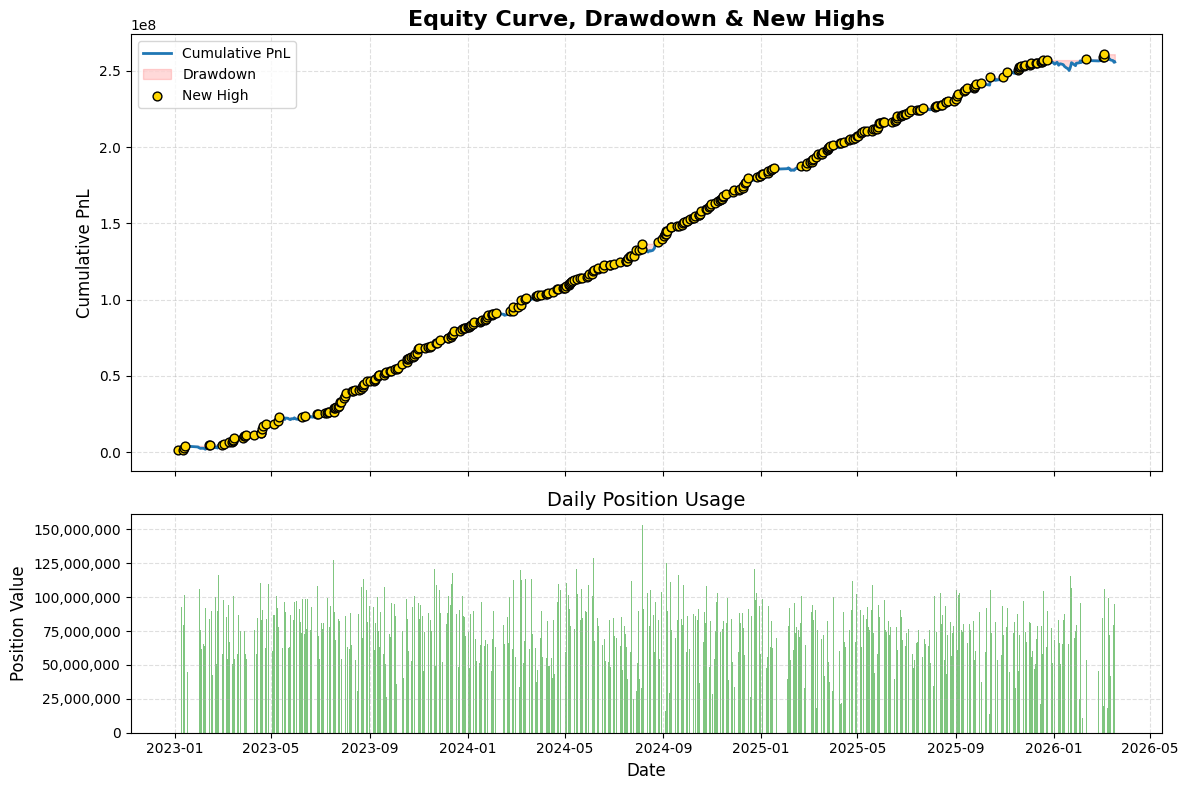


指標                 | 數值           

------------------ 基礎回報 ------------------
總報酬 (萬)           : 25,578.82
近一年報酬（萬）      : 6,045.08
風報比                  : 37.40
年化 Sharpe          : 6.26
創高最長費時 (天)     : 30
平均每日交易商品數   : 50.55

------------------ 勝率與效率 ------------------
年報酬率（基於平均部位）: 106.45%
近一年報酬率（近一年平均部位）: 85.92%
勝率 (日/單筆)      : 61.52% / 62.11%
平均BP (單/單位)   : 39.97 / 44.3523

------------------ 風控與部位 ------------------
單日最大虧損（萬） : -431.86 萬
MDD金額/佔平均比   : -683.93 萬 / 9.06%
平均/最大部位(萬)  : 7,548.69 / 15,339.55
平均最大單一商品比  : 3.12%



In [134]:
bt = BackTest(signalwithRisk_df)
results = bt.run_analysis()

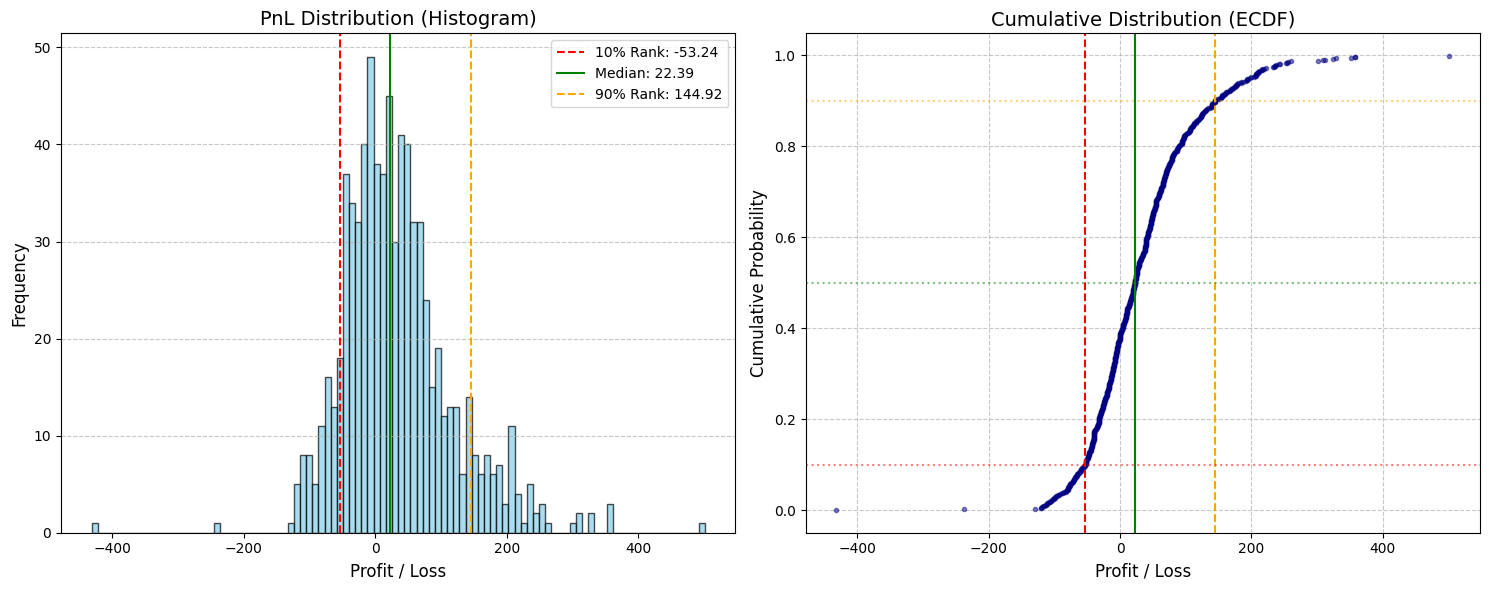

In [115]:

# 1. 計算分位數數值
q10 = series1.quantile(0.1)
q50 = series1.quantile(0.5)
q90 = series1.quantile(0.9)

# 2. 排序數據以計算累積機率 (ECDF)
sorted_data = np.sort(series1)
y_values = np.arange(len(sorted_data)) / float(len(sorted_data))

# 建立畫布
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# --- 圖左：直方圖 (棒狀圖) ---
axes[0].hist(series1, bins=100, color='skyblue', edgecolor='black', alpha=0.7)
# 加入垂直分界線
axes[0].axvline(q10, color='red', linestyle='--', linewidth=1.5, label=f'10% Rank: {q10:.2f}')
axes[0].axvline(q50, color='green', linestyle='-', linewidth=1.5, label=f'Median: {q50:.2f}')
axes[0].axvline(q90, color='orange', linestyle='--', linewidth=1.5, label=f'90% Rank: {q90:.2f}')

axes[0].set_title('PnL Distribution (Histogram)', fontsize=14)
axes[0].set_xlabel('Profit / Loss', fontsize=12)
axes[0].set_ylabel('Frequency', fontsize=12)
axes[0].legend() # 顯示圖例
axes[0].grid(axis='y', linestyle='--', alpha=0.7)

# --- 圖右：累積圖 (ECDF) ---
axes[1].plot(sorted_data, y_values, marker='.', linestyle='none', color='navy', alpha=0.5)
# 加入垂直分界線 (X軸：損益數值)
axes[1].axvline(q10, color='red', linestyle='--', linewidth=1.5)
axes[1].axvline(q50, color='green', linestyle='-', linewidth=1.5)
axes[1].axvline(q90, color='orange', linestyle='--', linewidth=1.5)
# 加入水平參考線 (Y軸：排名百分比)
axes[1].axhline(0.1, color='red', linestyle=':', alpha=0.5)
axes[1].axhline(0.5, color='green', linestyle=':', alpha=0.5)
axes[1].axhline(0.9, color='orange', linestyle=':', alpha=0.5)

axes[1].set_title('Cumulative Distribution (ECDF)', fontsize=14)
axes[1].set_xlabel('Profit / Loss', fontsize=12)
axes[1].set_ylabel('Cumulative Probability', fontsize=12)
axes[1].grid(True, linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()

In [116]:
# 計算所有天數的排名比例
series1 = ( signalwithRisk_df.BidPrice1 * (signalwithRisk_df.TakerSell_CloseBP - 19.3) / 10000 / 10).groupby(signalwithRisk_df.Date).sum()


In [117]:
date_portfolio = series1.reset_index().rename(columns={0: 'PL'})
date_portfolio['Position'] = ( signalwithRisk_df.BidPrice1 / 10).groupby(signalwithRisk_df.Date).sum().reset_index(drop=True)
date_portfolio['Return'] = date_portfolio['PL'] / date_portfolio['Position'] * 100

In [118]:
date_portfolio.describe()

,PL,Position,Return
count,764.000000,764.000000,764.000000
mean,33.480132,7548.687366,0.369188
std,84.906890,2189.525644,1.042532
min,-431.860710,198.630000,-4.715888
25%,-21.007339,6123.915000,-0.315520
50%,22.389533,7800.312500,0.312828
75%,71.534665,9056.477500,1.007020
max,501.058400,15339.545000,5.167334


In [119]:

from pathlib import Path
import os
PROJECT_ROOT = Path(os.path.abspath('')).parents[2]


dateData = []
for d in tqdm( date_portfolio.Date ) : 
    # 讀取 marketData
    maket_df = pd.read_parquet(f'{PROJECT_ROOT}/data/marketData/{d}_marketData.parquet')
    
    # 讀取 preMarketData (對應日期的每日特徵)
    premarket_df = pd.read_parquet(f'{PROJECT_ROOT}/data/preMarket/{d}_preMarketData.parquet')
    
    # 確保 key 都是字串型態以防合併錯誤
    maket_df['quote_code'] = maket_df['quote_code'].astype(str)
    premarket_df['QuoteCode'] = premarket_df['QuoteCode'].astype(str)
    
    # 合併兩個 DataFrame
    merged_df = pd.merge(
        maket_df, 
        premarket_df, 
        left_on='quote_code', 
        right_on='QuoteCode', 
        how='inner'
    )
    
    # 計算 toOpen
    merged_df['toOpen'] = (merged_df['open_price'] - merged_df['opening_ref_price']) / merged_df['opening_ref_price']
    merged_df['Return'] = (merged_df['close_price'] - merged_df['opening_ref_price']) / merged_df['opening_ref_price']

    tsmc = merged_df[merged_df['quote_code'] == '2330']
    tsmcOpen = tsmc.toOpen.iloc[0]
    tsmcReturn = tsmc.Return.iloc[0]
    # 2. day_amount_rank < 100 的 mean
    top_df = merged_df[merged_df['day_amount_rank'] < 100]
    topOpen = top_df.toOpen.mean(numeric_only=True)
    topDrop = top_df.toOpen.apply(np.sign).mean(numeric_only=True)
    topReturn = top_df.Return.mean(numeric_only=True)
    
    dateData.append( [tsmcOpen, tsmcReturn, topOpen, topDrop, topReturn])
    # break


100%|█████████▉| 763/764 [00:43<00:00, 17.60it/s]


KeyError: 'open_price'

In [ ]:
date_portfolio = pd.concat( [date_portfolio, pd.DataFrame(columns=['tsmOpen', 'tsmReturn', 'topOpen', 'topDrop', 'topReturn'], data = dateData) ], axis = 1)

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

def plot_qcut_analysis(df, col_a, col_b, date_col=None, split_date=None, q=5, isMin =False):
    """
    根據 col_a 的分位數繪製 col_b 的平均值。
    若提供 date_col 與 split_date，則會對比分割日期前後的表現。
    """
    # 1. 準備需要用的欄位，排除 NaN
    cols_to_keep = [col_a, col_b]
    if date_col is not None:
        cols_to_keep.append(date_col)
    
    temp_df = df[cols_to_keep].dropna().copy()
    
    # 2. 進行分箱 (qcut)
    temp_df['A_bins'] = pd.qcut(temp_df[col_a], q=q, duplicates='drop')
    
    # 判斷是否要進行時間分割
    do_split = (date_col is not None) and (split_date is not None)
    
    fig, ax = plt.subplots(figsize=(12, 6))
    
    # 內部標註數值函數
    def autolabel(rects):
        for rect in rects:
            height = rect.get_height()
            if pd.notna(height):
                va = 'bottom' if height >= 0 else 'top'
                offset = 3 if height >= 0 else -3
                ax.annotate(f'{height:.4f}',
                            xy=(rect.get_x() + rect.get_width() / 2, height),
                            xytext=(0, offset),
                            textcoords="offset points",
                            ha='center', va=va, fontsize=9)

    if do_split:
        # --- 模式 A: 前後期分割對照 ---
        mask_before = temp_df[date_col] < split_date
        mean_before = temp_df[mask_before].groupby('A_bins')[col_b].mean()
        mean_after = temp_df[~mask_before].groupby('A_bins')[col_b].mean()
        
        all_bins = mean_before.index.union(mean_after.index)
        mean_before = mean_before.reindex(all_bins)
        mean_after = mean_after.reindex(all_bins)
        
        x_labels = [f"({interval.left:.3g}, {interval.right:.3g}]" for interval in all_bins]
        x = np.arange(len(x_labels))
        width = 0.35
        
        rects1 = ax.bar(x - width/2, mean_before.values, width, 
                        label=f'Before {split_date}', color='skyblue', edgecolor='black', alpha=0.8)
        rects2 = ax.bar(x + width/2, mean_after.values, width, 
                        label=f'After {split_date}', color='salmon', edgecolor='black', alpha=0.8)
        
        autolabel(rects1)
        autolabel(rects2)
        title = f'Comparison: Mean of {col_b} by {col_a} (Split by {split_date})'
        ax.legend(fontsize=11)
        
    else:
        # --- 模式 B: 全期間單一分組 ---
        if isMin : 
            mean_total = temp_df.groupby('A_bins')[col_b].min()
        else : 
            mean_total = temp_df.groupby('A_bins')[col_b].mean()

        x_labels = [f"({interval.left:.3g}, {interval.right:.3g}]" for interval in mean_total.index]
        x = np.arange(len(x_labels))
        
        rects = ax.bar(x, mean_total.values, 0.6, color='lightgray', edgecolor='black', alpha=0.8, label='Full Period')
        
        autolabel(rects)
        if isMin : 
            title = f'Analysis: Min of {col_b} by {col_a} (Full Period)'
        else : 
            title = f'Analysis: Mean of {col_b} by {col_a} (Full Period)'

    # 圖表美化
    ax.set_title(title, fontsize=14)
    ax.set_xlabel(f'{col_a} Bins', fontsize=12)
    ax.set_ylabel(f'Average {col_b}', fontsize=12)
    ax.set_xticks(x)
    ax.set_xticklabels(x_labels, rotation=45, ha='right')
    ax.axhline(0, color='gray', linewidth=1, linestyle='--')
    ax.grid(axis='y', linestyle=':', alpha=0.6)
    
    plt.tight_layout()
    plt.show()

# --- 使用範例 ---
# 1. 只有分組繪圖 (不切日期)
# plot_qcut_analysis(df, 'Factor_A', 'Return')

# 2. 前後期對照 (切日期)
# plot_qcut_analysis(df, 'Factor_A', 'Return', date_col='Date', split_date=20240101)

In [ ]:
date_portfolio['topStd_10D'] = (date_portfolio.topReturn).rolling(10,min_periods=1).std().shift()
# date_portfolio['topReturnlast_10D'] = (date_portfolio.topOpen).rolling(10,min_periods=1).min().shift()

In [ ]:
date_portfolio['Count'] =  (date_portfolio.topOpen < 0.0018) | (date_portfolio.topReturnlast_10D < -0.025) 

<Axes: >

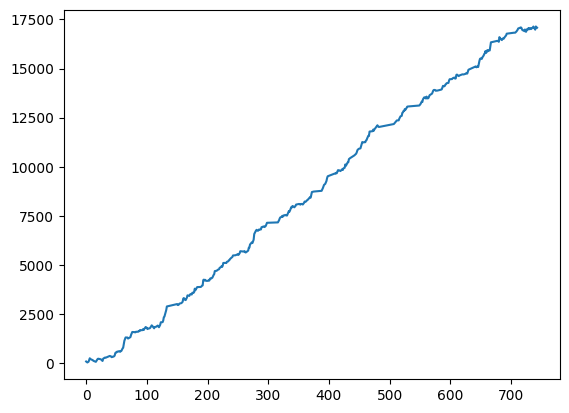

In [ ]:
date_portfolio[ date_portfolio ].PL.cumsum().plot()

In [ ]:
abonraml_DATE = date_portfolio[ (date_portfolio.Count ==True) ].Date

In [ ]:
abonraml_DATE

1      20230106
3      20230110
8      20230117
10     20230131
13     20230203
         ...   
758    20260311
759    20260312
760    20260313
761    20260316
762    20260317
Name: Date, Length: 352, dtype: str

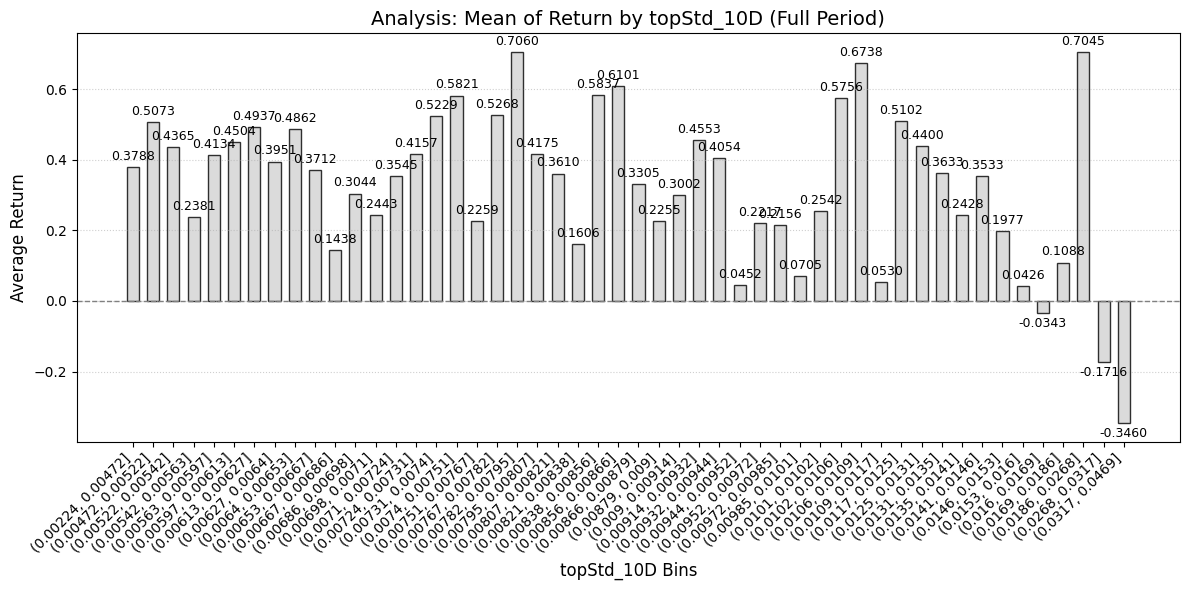

In [ ]:
plot_qcut_analysis(date_portfolio, col_a='topStd_10D', col_b=f'Return', q=50 , isMin=False)

In [ ]:
date_portfolio[]

In [ ]:
condition = date_portfolio.test > -0.005
print(condition.sum())
date_portfolio[ condition ].PL.cumsum().plot()

AttributeError: 'DataFrame' object has no attribute 'test'